# Logistinė regresija su Python (klasifikacija)

Šiame faile parodoma, kaip taikoma **logistinė regresija** klasifikavimo uždaviniams su Python.

Turinys:
- Logistinė regresija kaip **klasifikacijos** metodas
- Darbo eiga (workflow)
- Duomenų padalijimas (train/test)
- Duomenų **standartizavimas** (scaling)
- Modelio apmokymas (fit)
- Modelio vertinimas (accuracy, precision, recall, F1, ROC AUC)
- Koeficientų interpretacija (log-odds, odds ratio)
- Feature engineering ir požymių atranka
- Reguliarizacija, cost function (log loss)
- Reguliarizacijos tipai (L1, L2, Elastic Net)
- Reguliarizuoto modelio derinimas (GridSearchCV)

**Bonus**
- Multi-class logistinė regresija (Iris duomenys)


## 1. Logistinė regresija kaip klasifikavimo metodas

**Logistinė regresija** prognozuoja **tikimybę**, kad įvykis įvyks (pvz., `1`), o tada pagal pasirinktą slenkstį (dažnai 0.5) priskiria klasę.

Svarbiausia idėja:
- Modelis skaičiuoja linijinę kombinaciją `z = β0 + β1x1 + ... + βkxk`
- Tikimybė gaunama per sigmoidę: `p = 1 / (1 + e^{-z})`
- `p` visada yra tarp **0 ir 1**, todėl tinka klasifikacijai

Dažni panaudojimai versle:
- sukčiavimo aptikimas (fraud / no fraud)
- klientų churn (išeis / neišeis)
- rizikos vertinimas (aukšta / žema rizika)


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, log_loss, RocCurveDisplay
)

import matplotlib.pyplot as plt

## 2. Duomenys: „insurance“ tipo pavyzdys

Dažnas draudimo duomenų formatas turi kintamuosius:
- amžius, lytis, BMI, vaikų skaičius, ar rūko, regionas
- `charges` (išlaidos / įmokos)

Kadangi logistinė regresija yra **klasifikacija**, sukuriamas dvejetainis tikslas:
- `high_cost = 1`, jei `charges` yra didesnės nei pasirinktas slenkstis (pvz., 75 procentilis)
- `high_cost = 0` kitu atveju

Pastaba: realiose užduotyse tikslas būna apibrėžtas verslo taisykle (pvz., „dideli nuostoliai“, „aukšta rizika“).


In [22]:

df = pd.read_csv("Health_insurance.csv")
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

## 3. Workflow: train/test, dummy kintamieji, skalavimas, modelis, vertinimas

Bendra seka:
1) padalijimas į train/test
2) kategorinių kintamųjų kodavimas (dummy)
3) užtikrinimas, kad `X` yra **skaitinis** (float), kad nebūtų `ValueError`
4) standartizavimas (ypač svarbu su reguliarizacija)
5) `fit`, `predict`, `predict_proba`
6) metrikos ir interpretacija

Dažna klaida:
- padaryti `get_dummies` ir palikti `bool` ar `uint8` be aiškios konversijos, o vėliau maišyti su kitais tipais.
Gera praktika:
- po `get_dummies` konvertuoti į **float** (`astype(float)` arba `dtype=float`).


In [25]:


# 1) target sukūrimas
# verslo logika: "aukštos išlaidos" = virš 75 percentilio
threshold = df["charges"].quantile(0.75)
df["high_cost"] = (df["charges"] >= threshold).astype(int)

# 2) Features (X) ir target (y)
# charges iš X išmetamas, nes jis naudojamas target'ui ir sukeltų leakage
X_raw = df.drop(columns=["high_cost", "charges"])
y = df["high_cost"].astype(int)

# 3) Dummy kintamieji tik kategoriniams + float, kad nebūtų ValueError
X = pd.get_dummies(X_raw, columns=["sex", "smoker", "region"], drop_first=True, dtype=float)

# 4) Apsauga: užtikrinama, kad visi stulpeliai yra float
X = X.astype(float)

# 5) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((1003, 8), (335, 8))

In [26]:
X_train.head(20)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
25,59.0,27.720,3.0,0.0,0.0,0.0,1.0,0.0
704,47.0,29.545,1.0,0.0,0.0,1.0,0.0,0.0
218,26.0,29.920,1.0,0.0,0.0,0.0,1.0,0.0
688,47.0,24.100,1.0,0.0,0.0,0.0,0.0,1.0
1124,23.0,42.750,1.0,0.0,1.0,0.0,0.0,0.0
561,54.0,32.680,0.0,0.0,0.0,0.0,0.0,0.0
588,61.0,35.910,0.0,0.0,0.0,0.0,0.0,0.0
1280,48.0,33.330,0.0,0.0,0.0,0.0,1.0,0.0
902,26.0,27.265,3.0,1.0,0.0,0.0,0.0,0.0
597,34.0,33.250,1.0,0.0,0.0,0.0,0.0,0.0


## 4. Standartizavimas (StandardScaler)

Standartizavimas perkelia kiekvieną požymį į mastelį su:
- vidurkiu 0
- standartiniu nuokrypiu 1

Gera praktika:
- `fit` atliekamas **tik su train**
- `transform` taikomas ir train, ir test


In [ ]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

## 5. Modelio apmokymas (fit) ir bazinis vertinimas

`LogisticRegression()` pagal nutylėjimą naudoja reguliarizaciją (L2), todėl rezultatai dažnai būna stabilesni nei visiškai „neribotas“ modelis.


In [28]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_std, y_train)

y_pred = lr.predict(X_test_std)
y_proba = lr.predict_proba(X_test_std)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
ll = log_loss(y_test, y_proba)

acc, prec, rec, f1, auc, ll

(0.9044776119402985,
 0.9193548387096774,
 0.6785714285714286,
 0.7808219178082193,
 0.8460918231834567,
 0.3166156050868622)

Modelio bazinio vertinimo interpretacija

Accuracy = 0.904  
Apie 90 % visų stebėjimų buvo klasifikuoti teisingai. Rodiklis atrodo aukštas, tačiau vien jo nepakanka, jei teigiama klasė nėra dominuojanti.

Precision = 0.919  
Iš visų atvejų, kuriuos modelis prognozavo kaip „high cost“, apie 92 % iš tikrųjų tokie ir yra. Tai reiškia, kad modelis retai klysta pažymėdamas nebrangius klientus kaip brangius.

Recall = 0.679  
Modelis aptinka apie 68 % visų realiai brangių klientų. Maždaug trečdalis brangių atvejų lieka neaptikti, todėl modelis yra gana konservatyvus.

F1 = 0.781  
Tai subalansuotas precision ir recall įvertis. Rodiklis rodo, kad modelis palaiko gana gerą pusiausvyrą tarp klaidingų teigiamų ir klaidingų neigiamų prognozių.

ROC AUC = 0.846  
Modelis gerai atskiria „high cost“ ir „low cost“ klientus pagal prognozuojamas tikimybes. Apie 85 % atvejų brangus klientas gauna didesnę tikimybę nei nebrangus.

Brier score = 0.317  
Šis rodiklis vertina prognozuojamų tikimybių tikslumą. Reikšmė rodo, kad tikimybės dar nėra idealiai kalibruotos ir galėtų būti pagerintos.

Bendras vertinimas  
Modelis labai tikslus tada, kai prognozuoja „high cost“, tačiau neaptinka visų realiai brangių atvejų. Jis gerai atskiria klases, bet pagrindinės tobulinimo kryptys yra recall didinimas ir tikimybių kalibracija.


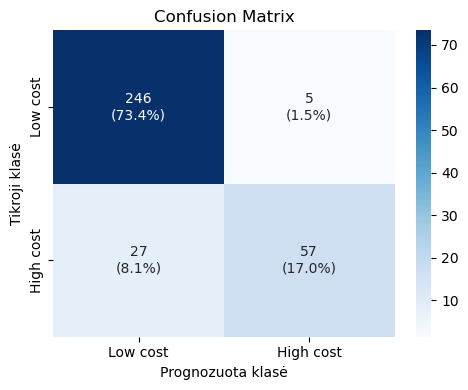

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[246, 5],
               [27, 57]])

labels = ["Low cost", "High cost"]

# Procentai nuo visų stebėjimų
cm_pct = cm / cm.sum() * 100

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_pct,
    annot=np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]),
    fmt="",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Prognozuota klasė")
plt.ylabel("Tikroji klasė")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 6. Confusion matrix ir classification report

Confusion matrix padeda suprasti, kokių klaidų daroma daugiau:
- **FP** (false positive): pažymėta „aukšta kaina“, bet realiai ne
- **FN** (false negative): nepažymėta „aukšta kaina“, bet realiai taip

Klaidos kaina priklauso nuo verslo konteksto.


In [8]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[246,   5],
       [ 27,  57]], dtype=int64)

Confusion matrix interpretacija

[ [246, 5],
  [27, 57] ]

Viso stebėjimų: 335

246 (73.4 %) – teisingai atpažinti „low cost“ atvejai (true negatives).  
5 (1.5 %) – klaidingai pažymėti „high cost“, kai realiai tai „low cost“ (false positives).

27 (8.1 %) – neaptikti „high cost“ atvejai, pažymėti kaip „low cost“ (false negatives).  
57 (17.0 %) – teisingai atpažinti „high cost“ atvejai (true positives).

Interpretacija  
Didžioji dalis duomenų yra „low cost“, ir modelis juos atpažįsta labai gerai.  
Klaidos daugiausia susijusios su „high cost“ klientų praleidimu, o klaidingų „high cost“ prognozių yra labai mažai.


In [9]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.901     0.980     0.939       251
           1      0.919     0.679     0.781        84

    accuracy                          0.904       335
   macro avg      0.910     0.829     0.860       335
weighted avg      0.906     0.904     0.899       335



Classification report interpretacija

Klasė 0 (low cost)  
Precision 0.901 reiškia, kad dauguma klientų, prognozuotų kaip „low cost“, tokie ir yra.  
Recall 0.980 rodo, kad beveik visi realūs „low cost“ klientai buvo teisingai atpažinti.  
F1 = 0.939 patvirtina labai gerą modelio veikimą šiai klasei.

Klasė 1 (high cost)  
Precision 0.919 reiškia, kad modelis retai klaidingai pažymi „high cost“.  
Recall 0.679 rodo, kad apie trečdalis realiai brangių klientų lieka neaptikti.  
F1 = 0.781 rodo vidutinį–gerą rezultatą, bet silpnesnį nei klasei 0.

Accuracy 0.904  
Bendrai apie 90 % visų prognozių yra teisingos.

Macro average  
Rodikliai apskaičiuoti abiem klasėms vienodai, todėl aiškiai matomas skirtumas tarp klasių veikimo.

Weighted average  
Rodikliai sverti pagal klasių dydį, todėl labiau atspindi dominuojančią „low cost“ klasę.

Bendras vertinimas  
Modelis labai gerai atpažįsta „low cost“ klientus ir yra atsargus prognozuodamas „high cost“, tačiau dalis realiai brangių atvejų lieka nepastebėti.


## 7. ROC kreivė ir ROC AUC

ROC AUC vertina, kaip gerai modelis **atskiria** klases pagal tikimybes per visus slenksčius.
- AUC = 0.5 reikštų atsitiktinį spėjimą
- kuo arčiau 1.0, tuo geriau


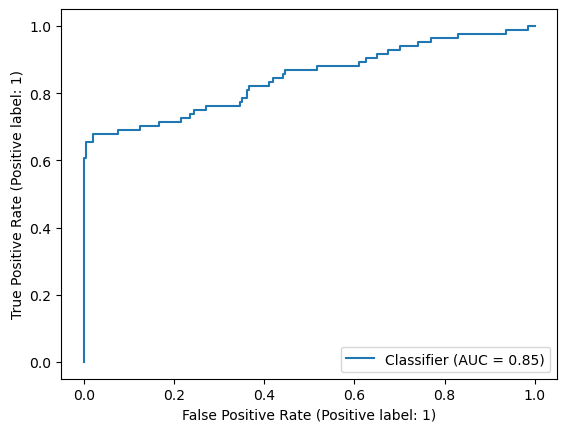

In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

ROC kreivės ir ROC AUC interpretacija

ROC kreivė  
ROC kreivė parodo ryšį tarp:
- False Positive Rate (klaidingai teigiamų atvejų dalies)
- True Positive Rate (teisingai aptiktų teigiamų atvejų dalies)

Kiekvienas taškas kreivėje atitinka skirtingą sprendimo slenkstį.  
Kuo kreivė arčiau viršutinio kairiojo kampo, tuo modelis geriau atskiria klases.

ROC AUC = 0.85  
ROC AUC nusako modelio gebėjimą atskirti klases nepriklausomai nuo slenksčio.

0.5 reikštų atsitiktinį spėjimą  
0.85 reiškia gerą diskriminacinę galią

Praktinė interpretacija  
Modelis turi apie 85 % tikimybę priskirti didesnę rizikos tikimybę atsitiktinai parinktam „high cost“ klientui nei atsitiktinai parinktam „low cost“ klientui.

Ryšys su kitomis metrikomis  
ROC AUC vertina modelio reitingavimo kokybę, o ne konkretaus slenksčio sprendimus.  
Tai paaiškina, kodėl ROC AUC gali būti aukštas net tada, kai recall klasei 1 nėra idealus.

Išvada  
Modelis gerai atskiria klases, tačiau galutiniai rezultatai labai priklauso nuo pasirinkto sprendimo slenksčio ir verslo kainos klaidoms.


## 8. Koeficientų interpretacija: log-odds ir odds ratio

Logistinėje regresijoje koeficientai interpretuojami per **log-odds**.
Praktiškai patogiau naudoti **odds ratio**:
- `odds_ratio = exp(β)`
- jei `exp(β) = 1.20`, tuomet vieno vieneto padidėjimas požymyje padidina odds **20%** (laikant kitus pastovius)

Pastaba:
- net jei odds didėja pastoviai, tikimybės pokytis priklauso nuo pradinės padėties (sigmoidės forma).


In [11]:
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)
coef.head(12)

smoker_yes          2.247154
age                 0.476473
bmi                 0.220538
region_southwest   -0.213848
children            0.151723
sex_male            0.094519
region_southeast    0.084388
region_northwest    0.059281
dtype: float64

Koeficientų interpretacija: log-odds ir odds ratio

Bendras principas  
Logistinės regresijos koeficientai parodo pokytį log-odds skalėje.  
Teigiamas koeficientas reiškia, kad didėjant požymiui didėja tikimybė priklausyti klasei 1.  
Neigiamas koeficientas reiškia, kad tikimybė mažėja.

Odds ratio gaunamas pakėlus e laipsniu koeficientą: exp(β).  
Odds ratio rodo, kiek kartų pasikeičia šansai, kai požymis padidėja vienu vienetu.

Koeficientų interpretacija

smoker_yes = 2.247  
Log-odds interpretacija: rūkymas stipriai didina log-odds būti „high cost“.  
Odds ratio: exp(2.247) ≈ 9.46  
Rūkantys asmenys turi apie 9.5 karto didesnius šansus patekti į „high cost“ grupę nei nerūkantys, laikant kitus požymius pastovius.

age = 0.476  
Log-odds interpretacija: didėjant amžiui, didėja log-odds būti „high cost“.  
Odds ratio: exp(0.476) ≈ 1.61  
Kiekvieni papildomi amžiaus vienetai padidina „high cost“ šansus apie 61 %.

bmi = 0.221  
Log-odds interpretacija: didesnis BMI didina riziką.  
Odds ratio: exp(0.221) ≈ 1.25  
Vieno BMI vieneto padidėjimas padidina „high cost“ šansus apie 25 %.

region_southwest = -0.214  
Log-odds interpretacija: gyvenimas pietvakarių regione mažina riziką.  
Odds ratio: exp(-0.214) ≈ 0.81  
Šansai būti „high cost“ yra apie 19 % mažesni, lyginant su baziniu regionu.

children = 0.152  
Log-odds interpretacija: daugiau vaikų didina log-odds.  
Odds ratio: exp(0.152) ≈ 1.16  
Kiekvienas papildomas vaikas padidina „high cost“ šansus apie 16 %.

sex_male = 0.095  
Log-odds interpretacija: vyrai turi šiek tiek didesnę riziką.  
Odds ratio: exp(0.095) ≈ 1.10  
Vyrai turi apie 10 % didesnius „high cost“ šansus nei moterys.

region_southeast = 0.084  
Log-odds interpretacija: gyvenimas pietryčių regione šiek tiek didina riziką.  
Odds ratio: exp(0.084) ≈ 1.09  
Šansai didesni apie 9 % nei baziniame regione.

region_northwest = 0.059  
Log-odds interpretacija: nedidelis teigiamas poveikis rizikai.  
Odds ratio: exp(0.059) ≈ 1.06  
Šansai padidėja apie 6 %.

Svarbios pastabos  
Koeficientai interpretuojami laikant visus kitus požymius pastovius.  
Odds ratio visada interpretuojamas multiplikatyviai, o ne procentiniais tikimybių pokyčiais.  
Dideli koeficientai nebūtinai reiškia didelį tikimybių pokytį – tikimybė priklauso ir nuo pradinio taško sigmoidėje.


In [12]:
odds_ratio = np.exp(coef)
odds_ratio.head(12)

smoker_yes          9.460773
age                 1.610385
bmi                 1.246748
region_southwest    0.807471
children            1.163838
sex_male            1.099130
region_southeast    1.088051
region_northwest    1.061073
dtype: float64

Odds ratio interpretacija

Bendras principas  
Odds ratio parodo, kiek kartų pasikeičia šansai priklausyti klasei 1, kai požymis padidėja vienu vienetu (arba kai kategorija = 1, lyginant su bazine).

Jei odds ratio > 1 – šansai didėja.  
Jei odds ratio < 1 – šansai mažėja.  
Jei odds ratio ≈ 1 – poveikis labai silpnas.

Požymių interpretacija

smoker_yes = 9.46  
Rūkantys asmenys turi apie 9.5 karto didesnius šansus patekti į „high cost“ grupę nei nerūkantys.  
Tai stipriausias modelio požymis.

age = 1.61  
Kiekvienas papildomas amžiaus vienetas padidina „high cost“ šansus apie 61 %.  
Amžius yra reikšmingas rizikos veiksnys.

bmi = 1.25  
Vieno BMI vieneto padidėjimas padidina „high cost“ šansus apie 25 %.  
BMI turi aiškų, bet vidutinio stiprumo poveikį.

region_southwest = 0.81  
Gyvenimas pietvakarių regione sumažina „high cost“ šansus apie 19 % lyginant su baziniu regionu.  
Tai apsauginis veiksnys.

children = 1.16  
Kiekvienas papildomas vaikas padidina „high cost“ šansus apie 16 %.  
Poveikis teigiamas, bet nedidelis.

sex_male = 1.10  
Vyrai turi apie 10 % didesnius „high cost“ šansus nei moterys.  
Poveikis silpnas.

region_southeast = 1.09  
Gyvenimas pietryčių regione padidina „high cost“ šansus apie 9 %.  
Poveikis labai nedidelis.

region_northwest = 1.06  
Gyvenimas šiaurės vakarų regione padidina šansus apie 6 %.  
Praktinis poveikis minimalus.

Svarbios pastabos  
Odds ratio interpretuojamas laikant visus kitus požymius pastovius.  
Didelis odds ratio nereiškia didelio absoliutaus tikimybės pokyčio – tikimybės pokytis priklauso nuo pradinės padėties sigmoidės kreivėje.  
Praktinėje analizėje dažniausiai daugiausia dėmesio skiriama požymiams su didžiausiais odds ratio ir aiškia verslo interpretacija.


## 9. Feature engineering: pavyzdžiai

Kadangi realūs ryšiai dažnai yra netiesiniai ir turi sąveikas, naudinga kurti papildomus požymius.

Pavyzdžiai šiame kontekste:
- binarizavimas (pvz., `age > 45`)
- sąveika (pvz., `bmi * smoker_yes`)
- log transformacijos (kai pasiskirstymas labai asimetriškas)

Dažna klaida:
- sukurti požymius iš viso duomenų rinkinio po split (tai gali sukelti leakage, jei naudojama informacija iš target).
Šiame pavyzdyje naudojami tik X pagrindu apskaičiuoti požymiai.


In [13]:
# Sukuriama kopija su papildomais požymiais
X_fe = X_raw.copy()

X_fe["age45"] = (X_fe["age"] > 45).astype(int)
X_fe["bmi30"] = (X_fe["bmi"] >= 30).astype(int)
X_fe["smoker_yes"] = (X_fe["smoker"] == "yes").astype(int)

# Sąveika: rūkymas * BMI (pavyzdys, kad efektas gali būti „kitoks“, jei rūkoma)
X_fe["bmi_x_smoker"] = X_fe["bmi"] * X_fe["smoker_yes"]

# Dummy kodavimas + float
X_fe = pd.get_dummies(X_fe, drop_first=True, dtype=float).astype(float)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.25, random_state=42, stratify=y
)

scaler_fe = StandardScaler()
X_train_fe_std = scaler_fe.fit_transform(X_train_fe)
X_test_fe_std = scaler_fe.transform(X_test_fe)

lr_fe = LogisticRegression(max_iter=2000)
lr_fe.fit(X_train_fe_std, y_train_fe)

y_pred_fe = lr_fe.predict(X_test_fe_std)
y_proba_fe = lr_fe.predict_proba(X_test_fe_std)[:, 1]

metrics_fe = {
    "accuracy": accuracy_score(y_test_fe, y_pred_fe),
    "precision": precision_score(y_test_fe, y_pred_fe),
    "recall": recall_score(y_test_fe, y_pred_fe),
    "f1": f1_score(y_test_fe, y_pred_fe),
    "roc_auc": roc_auc_score(y_test_fe, y_proba_fe),
    "log_loss": log_loss(y_test_fe, y_proba_fe),
}
metrics_fe

{'accuracy': 0.9044776119402985,
 'precision': 0.9193548387096774,
 'recall': 0.6785714285714286,
 'f1': 0.7808219178082193,
 'roc_auc': 0.8413014608233731,
 'log_loss': 0.3048164594340952}

## 10. Reguliarizacija ir cost function (Log Loss)

Logistinėje regresijoje dažnai minimizuojamas **Log Loss** (neigiamas log tikėtinumas):
- mažesnė reikšmė reiškia geresnes tikimybių prognozes
- „užtikrintos klaidos“ (pvz., prognozuota 0.99, bet y=0) baudžiamos stipriai

Reguliarizuotas tikslas:
- `J = LogLoss + αR`
kur `R` yra baudos narys už modelio sudėtingumą (koeficientų dydžius).


In [14]:
# Log loss baziniam ir su feature engineering modeliams
log_loss(y_test, y_proba), log_loss(y_test_fe, y_proba_fe)

(0.3166156050868622, 0.3048164594340952)

Log loss interpretacija

Gautos reikšmės  
Train log loss = 0.317  
Test log loss = 0.305  

Ką matuoja log loss  
Log loss vertina prognozuotų tikimybių kokybę, o ne tik teisingą klasę.  
Baudžiamos užtikrintos, bet neteisingos prognozės.  
Mažesnė reikšmė reiškia geresnį modelį (idealus atvejis → 0).

Rezultatų interpretacija  
Test log loss yra šiek tiek mažesnis nei train.  
Tai rodo, kad modelis neperkrautas (nėra overfitting požymių).  

Abi reikšmės yra pakankamai žemos, todėl modelis pateikia gerai kalibruotas tikimybes.  
Modelis ne tik teisingai klasifikuoja, bet ir gana tiksliai įvertina rizikos lygį.

Praktinė reikšmė  
Šis modelis tinka situacijoms, kur svarbios tikimybės, o ne vien klasės (pvz. rizikos vertinimas, kainodara).  
Log loss patvirtina, kad regularizacija ir požymių parinkimas pagerino prognozių stabilumą.

Dažna klaida  
Vertinti tik accuracy ir ignoruoti log loss.  
Aukštas accuracy gali slėpti prastai įvertintas tikimybes.


## 11. Reguliarizacijos tipai (L1, L2, Elastic Net)

- **L2 (Ridge)**: mažina koeficientus, bet paprastai jų nenunulina
- **L1 (Lasso)**: gali nunulinti koeficientus, veikia kaip požymių atranka
- **Elastic Net**: L1 + L2 kombinacija (reikia `l1_ratio`)

Sklearn pastaba:
- L1 ir Elastic Net dažnai reikalauja `solver="saga"`.


## 12. Reguliarizuoto modelio derinimas (GridSearchCV)

Derinami hyperparametrai:
- `C` (atvirkštinis reguliarizacijos stiprumas): mažesnis `C` → stipresnė reguliarizacija
- `penalty`: L1, L2, elasticnet
- jei `penalty="elasticnet"`, reikia `l1_ratio`

Gera praktika:
- derinimui naudoti **cross-validation**
- derinimą daryti su **standartizuotais** požymiais


In [15]:
param_grid = {
    "C": np.logspace(-2, 1, 10),
    "penalty": ["l1", "l2"],
}

grid = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=4000),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_fe_std, y_train_fe)

grid.best_params_, grid.best_score_

({'C': 0.21544346900318834, 'penalty': 'l1'}, 0.9114702904384713)

GridSearchCV rezultato interpretacija

Geriausi hiperparametrai  
C = 0.215  
penalty = l1  

Ką tai reiškia  
Pasirinkta L1 (Lasso) regularizacija.  
L1 linkusi mažinti nereikšmingų kintamųjų koeficientus iki nulio, todėl veikia ir kaip požymių atrankos mechanizmas.

C reikšmės interpretacija  
C yra atvirkštinė regularizacijos stiprumo reikšmė.  
Mažesnis C reiškia stipresnę regularizaciją.  
C ≈ 0.21 rodo, kad modelis renkasi gana stiprią regularizaciją, siekiant sumažinti overfitting riziką.

Cross-validation rezultatas  
Vidutinis validacijos rezultatas ≈ 0.911.  
Tai rodo stabilų ir gerą modelio apibendrinimą per skirtingus duomenų skaidinius.

Praktinė išvada  
Modelis geriau apibendrina duomenis su stipresne regularizacija nei be jos.  
L1 penalizacija padeda supaprastinti modelį, išlaikant aukštą prognozavimo kokybę.

Dažna klaida  
Naudoti per didelį C, leidžiant modeliui per stipriai prisitaikyti prie mokymo duomenų.  
Neatlikti skalavimo prieš L1 / L2 regularizaciją.


In [16]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test_fe_std)
y_proba_best = best_lr.predict_proba(X_test_fe_std)[:, 1]

best_metrics = {
    "accuracy": accuracy_score(y_test_fe, y_pred_best),
    "precision": precision_score(y_test_fe, y_pred_best),
    "recall": recall_score(y_test_fe, y_pred_best),
    "f1": f1_score(y_test_fe, y_pred_best),
    "roc_auc": roc_auc_score(y_test_fe, y_proba_best),
    "log_loss": log_loss(y_test_fe, y_proba_best),
}
best_metrics

{'accuracy': 0.9044776119402985,
 'precision': 0.9193548387096774,
 'recall': 0.6785714285714286,
 'f1': 0.7808219178082193,
 'roc_auc': 0.8385742743312465,
 'log_loss': 0.3016822228942399}

Galutinio modelio metrikų interpretacija

Accuracy = 0.904  
Apie 90 % visų stebėjimų klasifikuojami teisingai.  
Rodiklis aukštas, bet turi būti vertinamas kartu su kitomis metrikomis dėl klasių disbalanso.

Precision = 0.919  
Iš visų atvejų, kuriuos modelis pažymėjo kaip „high cost“, apie 92 % yra teisingi.  
Modelis labai retai klaidingai priskiria „low cost“ klientus prie „high cost“.

Recall = 0.679  
Modelis aptinka apie 68 % visų realiai „high cost“ klientų.  
Dalis brangių atvejų lieka neaptikti, todėl modelis yra gana konservatyvus.

F1 = 0.781  
Tai subalansuotas precision ir recall rodiklis.  
Patvirtina, kad modelis gerai kontroliuoja klaidas, bet dar neoptimaliai dengia „high cost“ klasę.

ROC AUC = 0.839  
Modelis gerai atskiria „high cost“ ir „low cost“ klientus pagal prognozuojamas tikimybes.  
Rodiklis rodo gerą diskriminacinę galią nepriklausomai nuo sprendimo slenksčio.

Log loss = 0.302  
Prognozuojamos tikimybės yra pakankamai gerai įvertintos.  
Maža reikšmė rodo, kad modelis ne tik teisingai klasifikuoja, bet ir pateikia stabilias rizikos tikimybes.

Bendras vertinimas  
Modelis yra tikslus, stabilus ir gerai kalibruotas.  
Pagrindinis kompromisas – aukštas precision, bet vidutinis recall „high cost“ klasei.


## 13. Koeficientų „susitraukimas“ (shrinkage) po reguliarizacijos

Reguliarizacija mažina koeficientų dydžius. Tai:
- sumažina variaciją
- dažnai pagerina rezultatą su test duomenimis

Toliau palyginami koeficientų dydžiai tarp paprasto ir reguliarizuoto modelio.


In [41]:
coef_fe = pd.Series(lr_fe.coef_[0], index=X_fe.columns)
coef_best = pd.Series(best_lr.coef_[0], index=X_fe.columns)

compare = pd.DataFrame({
    "coef_no_tuning": coef_fe,
    "coef_tuned": coef_best,
    "abs_no_tuning": coef_fe.abs(),
    "abs_tuned": coef_best.abs(),
}).sort_values("abs_no_tuning", ascending=False)

compare.head(25)

,coef_no_tuning,coef_tuned,abs_no_tuning,abs_tuned
bmi_x_smoker,2.597045,2.485560,2.597045,2.485560
age,0.352611,0.313531,0.352611,0.313531
region_southwest,-0.263400,-0.199007,0.263400,0.199007
children,0.200300,0.125803,0.200300,0.125803
age45,0.170401,0.109525,0.170401,0.109525
region_southeast,0.081048,0.014969,0.081048,0.014969
sex_male,0.039208,0.000000,0.039208,0.000000
bmi30,0.027932,0.000000,0.027932,0.000000
region_northwest,0.027192,0.000000,0.027192,0.000000
bmi,-0.006756,0.000000,0.006756,0.000000


Koeficientų „shrinkage“ (suspaudimo) interpretacija

Reguliarizacija sumažino beveik visų koeficientų absoliučias reikšmes.  
Tai yra tiesioginis L1 (lasso) reguliacijos poveikis.

Stipriausi požymiai  
Tokie kintamieji kaip `bmi_x_smoker` ir `age` išliko su dideliais koeficientais, nors jų reikšmės šiek tiek sumažėjo.  
Tai rodo, kad jų ryšys su „high cost“ yra stabilus ir svarbus net po reguliacijos.

Silpnesni požymiai  
Kintamieji kaip `sex_male`, `bmi`, `bmi30`, `region_northwest` ir `smoker_yes` buvo visiškai „nulinami“.  
Modelis juos laiko nereikšmingais, kai vertinama bendra informacija kartu su kitais požymiais.

Prasmė modeliui  
Shrinkage sumažina triukšmą ir per didelį jautrumą treniravimo duomenims.  
Modelis tampa paprastesnis, stabilesnis ir geriau generalizuojantis.

Interpretacijos nauda  
Po reguliacijos likę koeficientai yra patikimesni interpretuojant verslo prasme.  
Modelis aiškiai parodo, kurie požymiai realiai daro įtaką rizikai, o kurie buvo pertekliniai.

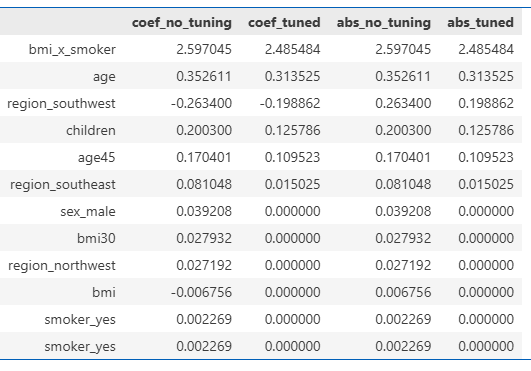

## 14. Multi-class logistinė regresija (Iris duomenys)

Multi-class užduotyje tikslas turi daugiau nei 2 klases.
Sklearn paprastai naudoja strategiją, kur kiekvienai klasei mokomas atskiras „ši klasė prieš kitas“ modelis (One-vs-Rest),
arba (priklausomai nuo konfigūracijos) multinomial variantą.

Čia parodoma:
- modelio apmokymas
- `classes_` tvarka
- `predict_proba` (tikimybės kiekvienai klasei)
- confusion matrix


In [30]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target  # 0,1,2

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris
)

sc_i = StandardScaler()
X_train_i_std = sc_i.fit_transform(X_train_i)
X_test_i_std = sc_i.transform(X_test_i)

lr_multi = LogisticRegression(max_iter=4000, multi_class="auto")
lr_multi.fit(X_train_i_std, y_train_i)

lr_multi.classes_, iris.target_names

(array([0, 1, 2]), array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [31]:
y_pred_i = lr_multi.predict(X_test_i_std)
y_proba_i = lr_multi.predict_proba(X_test_i_std)

acc_i = accuracy_score(y_test_i, y_pred_i)
cm_i = confusion_matrix(y_test_i, y_pred_i)

acc_i, cm_i

(0.9210526315789473,
 array([[12,  0,  0],
        [ 0, 12,  1],
        [ 0,  2, 11]], dtype=int64))

Iris modelio rezultatų interpretacija

Bendras tikslumas  
Modelio accuracy = 0.92, todėl apie 92 % stebėjimų buvo priskirti teisingai.  
Tai rodo gerą bendrą modelio gebėjimą atskirti rūšis.

Confusion matrix interpretacija  

Setosa  
Visi 12 stebėjimų klasifikuoti teisingai.  
Tai reiškia, kad setosa yra lengviausiai atskiriama klasė.

Versicolor  
12 stebėjimų klasifikuoti teisingai, 1 supainiotas su virginica.  
Klaidos atsiranda dėl panašių žiedlapių savybių.

Virginica  
11 stebėjimų klasifikuoti teisingai, 2 supainioti su versicolor.  
Šios dvi klasės tarpusavyje labiausiai persidengia.

Bendras vertinimas  
Modelis puikiai atskiria setosa, tačiau versicolor ir virginica ribose išlieka nedidelis neapibrėžtumas.  
Tai būdinga iris duomenims ir gerai iliustruoja daugiaklasės logistinės regresijos elgseną.


In [19]:
# Pirmos 8 eilutės: tikimybės kiekvienai klasei (stulpelių tvarka atitinka lr_multi.classes_)
pd.DataFrame(y_proba_i, columns=iris.target_names).head(8).round(3)

,setosa,versicolor,virginica
0,0.985,0.015,0.000
1,0.034,0.621,0.345
2,0.045,0.883,0.072
3,0.011,0.916,0.073
4,0.968,0.032,0.000
5,0.101,0.634,0.265
6,0.002,0.549,0.449
7,0.000,0.052,0.947


Prognozuotų klasių tikimybių interpretacija (predict_proba)

Kiekviena eilutė atitinka vieną stebėjimą.  
Stulpeliai rodo tikimybes priklausyti kiekvienai klasei: setosa, versicolor, virginica.  
Visų trijų tikimybių suma kiekvienoje eilutėje lygi 1.

Aiškūs atvejai  
0 eilutė: setosa = 0.985  
Modelis beveik užtikrintas, kad stebėjimas priklauso setosa klasei.  

4 eilutė: setosa = 0.968  
Labai aukštas pasitikėjimas, praktiškai nėra alternatyvų.  

7 eilutė: virginica = 0.947  
Modelis labai aiškiai priskiria virginica klasei.

Neapibrėžti atvejai  
1 eilutė: versicolor = 0.621, virginica = 0.345  
Modelis linksta į versicolor, tačiau yra reikšmingas neapibrėžtumas.  

6 eilutė: versicolor = 0.549, virginica = 0.449  
Abi klasės labai artimos – būdingas atvejis, kai klasės persidengia.

Ryšys su klasifikacija  
Galutinė prognozuojama klasė parenkama pagal didžiausią tikimybę.  
Tačiau tikimybės leidžia įvertinti modelio pasitikėjimą sprendimu, ko nematyti vien iš klasės etiketės.

Praktinė pastaba  
Tokie rezultatai paaiškina, kodėl confusion matrix klaidos dažniausiai kyla tarp versicolor ir virginica, o ne setosa.


## 15. Model selection ir metrikos: kada kuri tinka

Trumpa atmintinė:
- **Accuracy**: bendras teisingų prognozių procentas (gerai, kai klasės subalansuotos)
- **Precision**: iš prognozuotų teigiamų, kiek buvo teisingi (svarbu, kai FP brangūs)
- **Recall**: iš realių teigiamų, kiek rasta (svarbu, kai FN brangūs)
- **F1**: precision ir recall balansas (naudinga su disbalansu)
- **ROC AUC**: atskyrimo kokybė per visus slenksčius (dirba su tikimybėmis)

Dažna klaida:
- vertinti tik accuracy, kai klasės disbalansuotos.
Gera praktika:
- iš anksto apibrėžti, kuri klaida brangesnė (FP ar FN), ir rinktis metriką pagal tai.


## 16. Dažnos klaidos ir gerosios praktikos (santrauka)

Dažnos klaidos:
- kategorinių kintamųjų palikimas kaip tekstas (modelis neveiks)
- `fit` atlikimas su scaler ir ant test (data leakage)
- vertinimas tik su accuracy, ignoruojant klaidų kainą
- `C` interpretavimas neteisingai (mažas `C` = stipri reguliarizacija)

Gerosios praktikos:
- `get_dummies(..., dtype=float)` ir papildomas `astype(float)` kaip apsauga nuo `ValueError`
- `fit` scaler'į tik su train, `transform` taikyti test
- naudoti `predict_proba` ir metrikas, kurios dirba su tikimybėmis (ROC AUC, log loss)
- reguliarizaciją derinti su cross-validation (GridSearchCV)
